### Mortgage Probability of Default
### Yilin Luo

## Section 1. Feature Engineering

In [235]:
#!pip install scikit-learn pandas numpy matplotlib seaborn plotly pycaret category_encoders

In [3]:
# data
import pandas as pd
import numpy as np

# visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
#import missingno as msno
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
#from wordcloud import WordCloud

from sklearn import datasets
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# styling
%matplotlib inline
sns.set_style('darkgrid')
mpl.rcParams['font.size'] = 12
mpl.rcParams['figure.facecolor'] = '#00000000'
mpl.rcParams['font.size'] = 12
mpl.rcParams['figure.facecolor'] = '#00000000'

import os 
#from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

### Load and Prepare Data

In [436]:
path = '/Users/yilin/Downloads'
data =  pd.read_csv(path + "/XYZloan_default_llm.csv")

In [437]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 32 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  16000 non-null  int64  
 1   Unnamed: 0    16000 non-null  int64  
 2   AP001         16000 non-null  int64  
 3   AP002         16000 non-null  int64  
 4   AP003         16000 non-null  int64  
 5   AP006         16000 non-null  object 
 6   AP007         16000 non-null  int64  
 7   AP008         16000 non-null  int64  
 8   CR004         16000 non-null  int64  
 9   CR009         16000 non-null  int64  
 10  CR015         16000 non-null  int64  
 11  CR017         16000 non-null  int64  
 12  CR018         16000 non-null  int64  
 13  CR019         16000 non-null  int64  
 14  MB005         15441 non-null  float64
 15  MB007         16000 non-null  object 
 16  PA022         15918 non-null  float64
 17  PA023         15918 non-null  float64
 18  PA028         15918 non-nu

In [438]:
# assign new column name using variables dictionary
columns = {
    'AP001': 'YR_AGE',
    'AP002': 'CODE_GENDER',
    'AP003': 'CODE_EDUCATION',
    'AP006': 'OS_TYPE',
    'AP007': 'LEVEL_APPL_CITY',
    'AP008': 'FLAG_IP_CITY_NOT_APPL_CITY',
    'CR004': 'CNT_QUERY_TIME_LAST_1MON',
    'CR009': 'AMT_LOAN_TOTAL',
    'CR015': 'MONTH_CREDIT_CARD_MOB_MAX',
    'CR017': 'SCORE_DEBIT_CARD_TOTAL_AMT',
    'CR018': 'SCORE_DEBIT_CARD_UTILITY_AMT',
    'CR019': 'SCORE_SINGLE_DEBIT_CARD_LIMIT',
    'MB005': 'YR_PHONE_ACTIVE',
    'MB007': 'Application_Device',
    'PA022': 'DAYS_BTW_APP_AND_FIRST_COLLECTION_OR_HIGH_RISK_CALL',
    'PA023': 'DAYS_BTW_APP_AND_FIRST_COLLECTION_CALL',
    'PA028': 'AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS',
    'PA029': 'AVG_LEN_COLLECTION_OR_HIGH_RISK_INBOUND_CALLS',
    'PA031': 'AVG_LEN_COLLECTION_CALLS',
    'TD001': 'TD_CNT_QUERY_LAST_7Day_P2P',
    'TD002': 'TD_CNT_QUERY_LAST_7Day_SMALL_LOAN',
    'TD003': 'TD_CNT_QUERY_LAST_7Day_BANK',
    'TD004': 'TD_CNT_QUERY_LAST_7Day_OTHER',
    'TD005': 'TD_CNT_QUERY_LAST_1MON_P2P',
    'TD006': 'TD_CNT_QUERY_LAST_1MON_SMALL_LOAN',
    'TD007': 'TD_CNT_QUERY_LAST_1MON_BANK',
    'TD008': 'TD_CNT_QUERY_LAST_1MON_OTHER',
    'TD009': 'TD_CNT_QUERY_LAST_3MON_P2P',
    'TD010': 'TD_CNT_QUERY_LAST_3MON_SMALL_LOAN',
    'TD011': 'TD_CNT_QUERY_LAST_3MON_BANK',
    'TD012': 'TD_CNT_QUERY_LAST_3MON_OTHER',
    'TD013': 'TD_CNT_QUERY_LAST_6MON_P2P',
    'TD014': 'TD_CNT_QUERY_LAST_6MON_SMALL_LOAN',
    'TD015': 'TD_CNT_QUERY_LAST_6MON_BANK',
    'TD016': 'TD_CNT_QUERY_LAST_6MON_OTHER',
    'TD022': 'TD_CNT_QUERY_LAST_24MON_SMALL_LOAN',
    'TD024': 'TD_CNT_QUERY_LAST_24MON_OTHER',
    'loan_default': 'Loan_Default',
    
}

# apply to your DataFrame
data = data.rename(columns=columns)

In [439]:
# drop three unused columns
data = data.drop(columns=['Unnamed: 0.1', 'Unnamed: 0', 'reason'])

In [388]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 29 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   YR_AGE                                               16000 non-null  int64  
 1   CODE_GENDER                                          16000 non-null  int64  
 2   CODE_EDUCATION                                       16000 non-null  int64  
 3   OS_TYPE                                              16000 non-null  object 
 4   LEVEL_APPL_CITY                                      16000 non-null  int64  
 5   FLAG_IP_CITY_NOT_APPL_CITY                           16000 non-null  int64  
 6   CNT_QUERY_TIME_LAST_1MON                             16000 non-null  int64  
 7   AMT_LOAN_TOTAL                                       16000 non-null  int64  
 8   MONTH_CREDIT_CARD_MOB_MAX                            16000 non-nul

In [389]:
# Identify all object-dtype columns as categorical
cat_var = data.select_dtypes(include=['object']).columns.tolist()

# Identify all numeric columns (int64 & float64) as numeric
num_var = data.select_dtypes(include=['number']).columns.tolist()

# Remove the target from num_var (if it’s numeric)
target = 'Loan_Default'
if target in num_var:
    num_var.remove(target)

# Combine
X_vars = cat_var + num_var

In [390]:
# Verify
print("Categorical variables:", cat_var)

Categorical variables: ['OS_TYPE', 'Application_Device']


In [391]:
print("Numeric variables:", num_var)

Numeric variables: ['YR_AGE', 'CODE_GENDER', 'CODE_EDUCATION', 'LEVEL_APPL_CITY', 'FLAG_IP_CITY_NOT_APPL_CITY', 'CNT_QUERY_TIME_LAST_1MON', 'AMT_LOAN_TOTAL', 'MONTH_CREDIT_CARD_MOB_MAX', 'SCORE_DEBIT_CARD_TOTAL_AMT', 'SCORE_DEBIT_CARD_UTILITY_AMT', 'SCORE_SINGLE_DEBIT_CARD_LIMIT', 'YR_PHONE_ACTIVE', 'DAYS_BTW_APP_AND_FIRST_COLLECTION_OR_HIGH_RISK_CALL', 'DAYS_BTW_APP_AND_FIRST_COLLECTION_CALL', 'AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS', 'AVG_LEN_COLLECTION_OR_HIGH_RISK_INBOUND_CALLS', 'AVG_LEN_COLLECTION_CALLS', 'TD_CNT_QUERY_LAST_7Day_P2P', 'TD_CNT_QUERY_LAST_1MON_P2P', 'TD_CNT_QUERY_LAST_1MON_SMALL_LOAN', 'TD_CNT_QUERY_LAST_3MON_P2P', 'TD_CNT_QUERY_LAST_3MON_SMALL_LOAN', 'TD_CNT_QUERY_LAST_6MON_P2P', 'TD_CNT_QUERY_LAST_6MON_SMALL_LOAN', 'TD_CNT_QUERY_LAST_24MON_SMALL_LOAN', 'TD_CNT_QUERY_LAST_24MON_OTHER']


In [392]:
print("Target:", target)

Target: Loan_Default


In [393]:
data[target].value_counts()

Loan_Default
0    12924
1     3076
Name: count, dtype: int64

### Train-Test Split

In [394]:
# split the data (70% of the data for training and 30% for testing)
X = data.drop(target, axis=1)
y = data[target]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
[X_train.shape,X_test.shape, y_train.shape, y_test.shape]

[(12000, 28), (4000, 28), (12000,), (4000,)]

### Target/mean encoding (Feature enhancement for the categorical variables)

In [395]:
# Show the code to use "target_encoder" for mean encoding
# Create a new set of mean-encoded variables for the categorical variables
# Use the X-train to get the mean first then apply to the test data.

from category_encoders import target_encoder as te
ec = te.TargetEncoder()

X_train_m = pd.DataFrame()
X_test_m = pd.DataFrame()

for var in cat_var:
    X_train_m[var+'_D'] = ec.fit_transform(X_train[var],y_train)
    X_test_m[var+'_D'] = ec.transform(X_test[var])

X_train_m

,OS_TYPE_D,Application_Device_D
8928,0.188905,0.189318
9895,0.188905,0.189318
14163,0.220118,0.245247
14352,0.180544,0.164782
15916,0.180544,0.178959
...,...,...
13123,0.188905,0.189318
3264,0.188905,0.189318
9845,0.188905,0.189318
10799,0.180544,0.178959


### Perform mean imputation for missing values on continuous variables

In [396]:
# Provide the code to check the variables that have missing value.
# Get the means from the training data
# Apply the means to the train data
# Apply the means to the test data

# Check 
# Find columns with missing values for the numerical columns
X_train_numvar = X_train[num_var]
missing_columns = X_train_numvar.columns[X_train_numvar.isnull().sum() > 0]

# Display the columns with missing values
missing_columns

Index(['YR_PHONE_ACTIVE',
       'DAYS_BTW_APP_AND_FIRST_COLLECTION_OR_HIGH_RISK_CALL',
       'DAYS_BTW_APP_AND_FIRST_COLLECTION_CALL',
       'AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS',
       'AVG_LEN_COLLECTION_OR_HIGH_RISK_INBOUND_CALLS',
       'AVG_LEN_COLLECTION_CALLS', 'TD_CNT_QUERY_LAST_24MON_SMALL_LOAN',
       'TD_CNT_QUERY_LAST_24MON_OTHER'],
      dtype='object')

In [397]:
for col in missing_columns:
    # Calculate the mean of the column (ignoring NaNs)
    mean_value = X_train[col].mean()
    
    # Impute the missing values in both X_train and X_test
    X_train[col].fillna(mean_value, inplace=True)
    X_test[col].fillna(mean_value, inplace=True)

### Modeling data

In [398]:
X_train_model = pd.concat([X_train_m, X_train[num_var]], axis=1)
X_train_model.shape

X_test_model = pd.concat([X_test_m, X_test[num_var]], axis=1)
[X_train_model.shape, X_test_model.shape]

[(12000, 28), (4000, 28)]

## Section 2: Use randomized search to build models

### Build and fine-tune the decision tree model

In [399]:
# if y_train is a numpy array, wrap in a Series first
y = pd.Series(y_train)

# compute the counts sorted by class label, name the Series “Count”
count_series = y.value_counts().sort_index().rename("Count")

# turn it into a one-column DataFrame
count_df = count_series.to_frame()

print(count_df)

              Count
Loan_Default       
0              9670
1              2330


As the y_train table showed above, the class weight is imbalanced, which means the model may ignore class 1 entirely. In this case, when we build the model, we will specify class_weight='balanced'.

In [400]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier # for classification
from sklearn.tree import DecisionTreeRegressor # for regression

# Define the parameter distributions
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [5, 10, 20],
    'min_samples_split': [10, 20, 50],
    'criterion': ['gini', 'entropy']
}

dtree = DecisionTreeClassifier(random_state=42,class_weight='balanced')

# Set up the randomized search
random_search = RandomizedSearchCV(
    estimator=dtree,
    param_distributions=param_grid,
    n_iter=20,              # Number of parameter settings sampled
    scoring='roc_auc',     # Metric to optimize
    cv=5,                   # 5-fold cross-validation
    random_state=42,
    n_jobs=-1               # Use all CPU cores
)

# Fit the search to training data
random_search.fit(X_train_model, y_train)

RandomizedSearchCV(cv=5,
                   estimator=DecisionTreeClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 5, 7, 10, None],
                                        'min_samples_leaf': [5, 10, 20],
                                        'min_samples_split': [10, 20, 50]},
                   random_state=42, scoring='roc_auc')

In [401]:
# Get the best model
best_dtree_model = random_search.best_estimator_

### Build and Fine-tune the Logistic model

In [402]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
from scipy.stats import loguniform

# Define the logistic regression model
logreg = LogisticRegression(max_iter=1000, solver='liblinear',class_weight='balanced')

# Define the parameter distributions
param_distributions = {
    'C': loguniform(0.001, 1),    # Strong regularization
    'penalty': ['l1', 'l2']         # Type of regularization
}

# Set up the randomized search
random_search = RandomizedSearchCV(
    estimator=logreg,
    param_distributions=param_distributions,
    n_iter=20,              # Number of parameter settings sampled
    scoring='accuracy',     # Metric to optimize
    cv=5,                   # 5-fold cross-validation
    random_state=42,
    n_jobs=-1               # Use all CPU cores
)

# Using randomized search
#random_search.fit(X_train_model, y_train)

# Not using randomized search to save time. The result will not be optimized.
# You are advised to use the randomized search.
logreg.fit(X_train_model, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')

In [403]:
# Not using the randomized search to save time
best_logistic_model = logreg

### Visualize the feature importance of decision tree

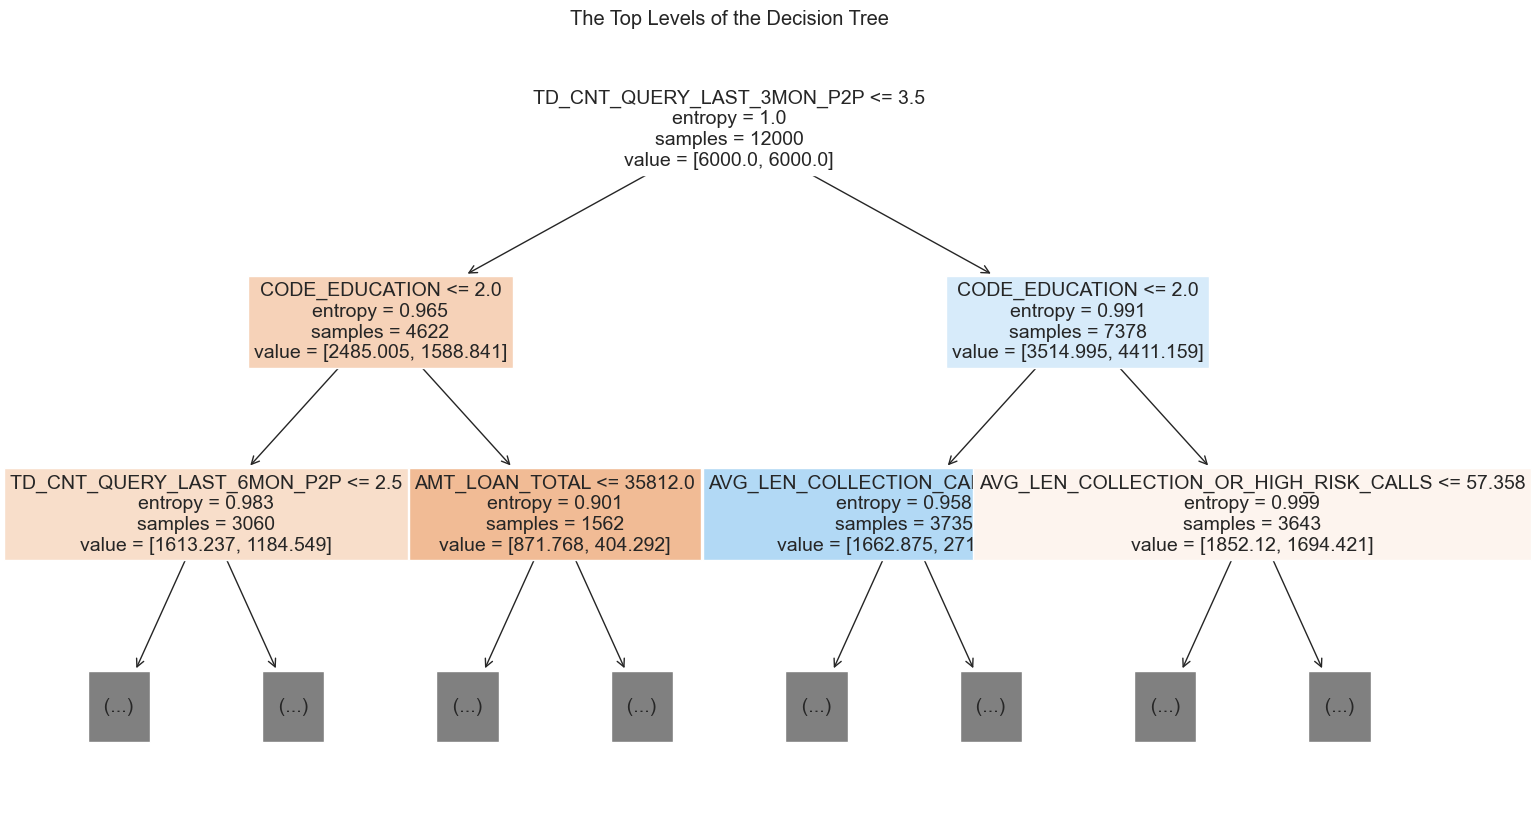

In [404]:
# Show the code to visualize the decision tree. Show only the top two levels.

plt.figure(figsize=(18,10))
plot_tree(best_dtree_model, filled=True, max_depth=2, feature_names=X_train_model.columns, fontsize=14)
plt.title("The Top Levels of the Decision Tree")
plt.show()

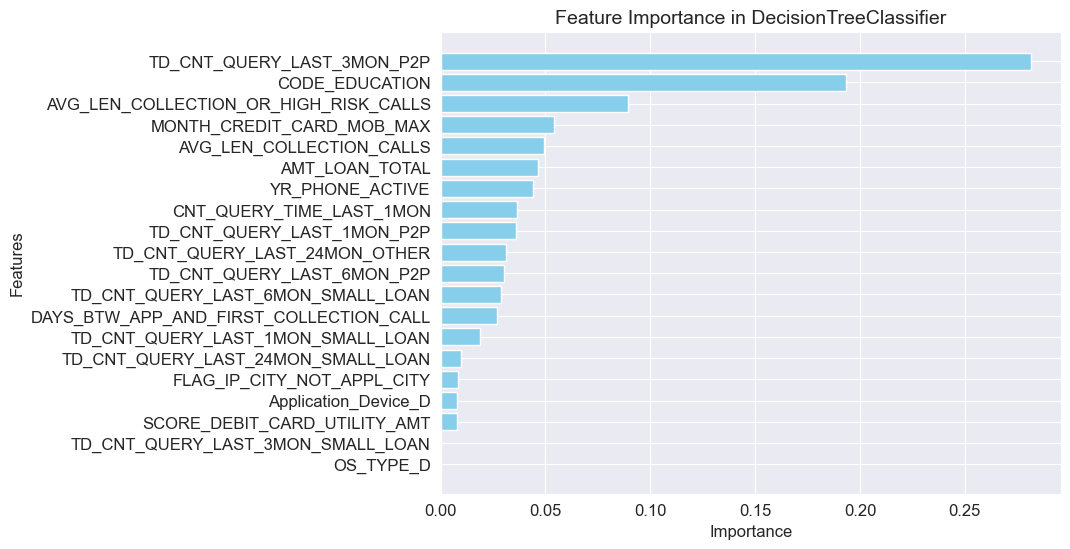

In [405]:
# Get feature importances
# Create a DataFrame for visualization
# Plot the feature importance chart

importances = best_dtree_model.feature_importances_
feature_names = X_train_model.columns
# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)[0:20]

plt.figure(figsize=(8, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance in DecisionTreeClassifier', fontsize=14)
plt.gca().invert_yaxis()  # Optional: Show the most important features on top
plt.show()

## Section 3: Prediction

### Decision tree model

In [406]:
best_dtree_train_proba = best_dtree_model.predict_proba(X_train_model)
best_dtree_test_proba = best_dtree_model.predict_proba(X_test_model)
best_dtree_test_proba

array([[0.45830814, 0.54169186],
       [0.50155985, 0.49844015],
       [0.34082227, 0.65917773],
       ...,
       [0.6351252 , 0.3648748 ],
       [0.60222904, 0.39777096],
       [0.45830814, 0.54169186]])

In [407]:
best_dtree_train_pred = best_dtree_model.predict(X_train_model) 
best_dtree_test_pred = best_dtree_model.predict(X_test_model)
best_dtree_test_pred

array([1, 0, 1, ..., 0, 0, 1])

### Logistic model

In [408]:
best_logistic_train_proba = best_logistic_model.predict_proba(X_train_model)
best_logistic_test_proba = best_logistic_model.predict_proba(X_test_model)
best_logistic_test_proba

array([[0.40667602, 0.59332398],
       [0.42470045, 0.57529955],
       [0.59287781, 0.40712219],
       ...,
       [0.74420454, 0.25579546],
       [0.60421061, 0.39578939],
       [0.43181366, 0.56818634]])

In [409]:
best_logistic_train_pred = best_logistic_model.predict(X_train_model)
best_logistic_test_pred = best_logistic_model.predict(X_test_model)
best_logistic_test_pred

array([1, 1, 0, ..., 0, 0, 1])

## Section 4: Evaluate Model Performance

### 4.1 Accuracy

#### Decision tree model

In [410]:
# For decision tree model, show the code to provide the accuracy score for the train and test data

from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
print('The test data:',accuracy_score(y_test,best_dtree_test_pred))

The test data: 0.57325


#### Logistic model

In [411]:
# For logistic model, show the code to provide the accuracy score for the train and test data

print('The test data:',accuracy_score(y_test,best_logistic_test_pred))

The test data: 0.6385


### 4.2 Confusion matrix

#### Decision tree model

In [412]:
# For decision tree model, provide the confusion matrix. Format it into a data frame.

best_dtree_cm = pd.DataFrame(confusion_matrix(y_test,best_dtree_test_pred))
best_dtree_cm.rename(columns={0:'Predicted Negative', 1:'Predicted Positive'},
         index = {0:'Actual Negative',1:'Actual Positive'},inplace=True)
best_dtree_cm

,Predicted Negative,Predicted Positive
Actual Negative,1869,1385
Actual Positive,322,424


#### Logistic model

In [413]:
# For logistic model, provide the confusion matrix. Format it into a data frame.

best_logistic_cm = pd.DataFrame(confusion_matrix(y_test,best_logistic_test_pred))
best_logistic_cm.rename(columns={0:'Predicted Negative', 1:'Predicted Positive'},
         index = {0:'Actual Negative',1:'Actual Positive'},inplace=True)
best_logistic_cm

,Predicted Negative,Predicted Positive
Actual Negative,2105,1149
Actual Positive,297,449


### 4.3 AUC-ROC

#### Decision tree model

In [414]:
# provide the roc_auc_value for the test data

best_dtree_roc_auc_value = roc_auc_score(y_test,best_dtree_test_pred)
best_dtree_roc_auc_value

0.5713673087031675

#### Logistic model

In [415]:
# provide the roc_auc_value for the test data

best_logistic_roc_auc_value = roc_auc_score(y_test,best_logistic_test_pred)
best_logistic_roc_auc_value

0.6243864017229362

### 4.4 Plot ROC curve

#### Decision tree model

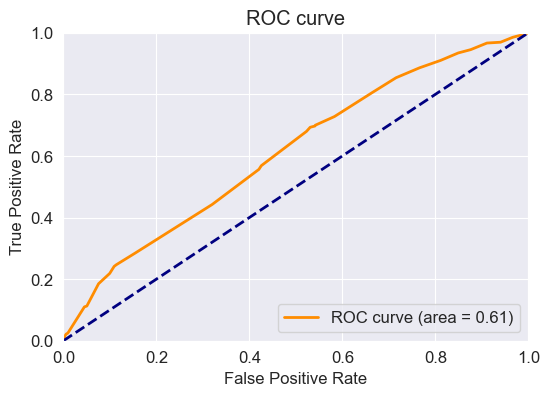

In [416]:
def plot_roc(y_true,y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_value = roc_auc_score(y_true,y_prob)
    lw=2
    plt.figure(figsize=(6,4))
    plt.plot(fpr,tpr, color='darkorange',lw=lw,label='ROC curve (area = %0.2f)' %roc_auc_value)
    plt.plot([0,1],[0,1], color='navy',lw=lw,linestyle='--')
    plt.xlim([0,1])
    plt.ylim([0,1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curve')
    plt.legend(loc='lower right')
    plt.show()
    
plot_roc(y_test, best_dtree_test_proba[:,1])

#### Logistic model

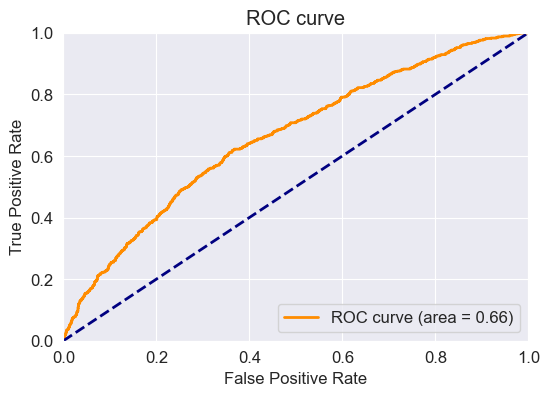

In [417]:
# For your logistic model, please plot the ROC curve for the test data
plot_roc(y_test, best_logistic_test_proba[:,1])

### 4.5 The Precision-Recall Curve

#### Decision tree model


   * ROC curve: The ROC curve plots the true positive rate vs. the false rositive sate

	  * The area under the curve (AUC): A value between 0.5 (random) and 1.0 (perfect), measuring the prediction accuracy

   * Recall (R) = The number of true positives / (the number of true positives + the number of false negatives)



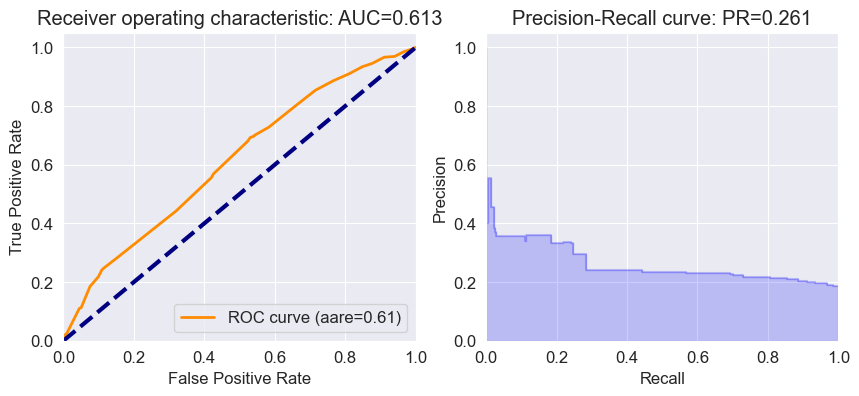

In [418]:
# plot the ROC and the Precision-Recall curve for the test data


from sklearn.metrics import roc_curve, auc, average_precision_score, precision_recall_curve

def ROC_PR(y_actual, y_pred):
    # ROC
    fpr = list()
    tpr = list()
    roc_auc = list()
    fpr,tpr,_ = roc_curve(y_actual,y_pred)
    roc_auc = auc(fpr,tpr)
    
    # Precision-Recall
    average_precision = average_precision_score(y_actual,y_pred)

    print('')
    print('   * ROC curve: The ROC curve plots the true positive rate vs. the false rositive sate')
    print('')
    print('	  * The area under the curve (AUC): A value between 0.5 (random) and 1.0 (perfect), measuring the prediction accuracy')
    print('')
    print('   * Recall (R) = The number of true positives / (the number of true positives + the number of false negatives)')
    print('')
    
    # plotting
    plt.figure(figsize=(10,4))

    # ROC
    plt.subplot(1,2,1)
    plt.plot(fpr,tpr,color='darkorange',lw=2,label='ROC curve (aare=%0.2f)' % roc_auc)
    plt.plot([0,1],[0,1],color='navy',lw=3,linestyle='--')
    plt.xlim([0.0,1.0])
    plt.ylim([0.0,1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic: AUC={0:0.3f}'.format(roc_auc))
    plt.legend(loc='lower right')

    # Precision-Recall
    plt.subplot(1,2,2)
    precision,recall,_ = precision_recall_curve(y_actual,y_pred)
    plt.step(recall,precision,color='b',alpha=0.2,where='post')
    plt.fill_between(recall,precision,step='post',alpha=0.2,color='b')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.ylim([0.0,1.05])
    plt.xlim([0.0,1.0])
    plt.title('Precision-Recall curve: PR={0:0.3f}'.format(average_precision))
    plt.show()
    
ROC_PR(y_test, best_dtree_test_proba[:,1])

#### Logistic model


   * ROC curve: The ROC curve plots the true positive rate vs. the false rositive sate

	  * The area under the curve (AUC): A value between 0.5 (random) and 1.0 (perfect), measuring the prediction accuracy

   * Recall (R) = The number of true positives / (the number of true positives + the number of false negatives)



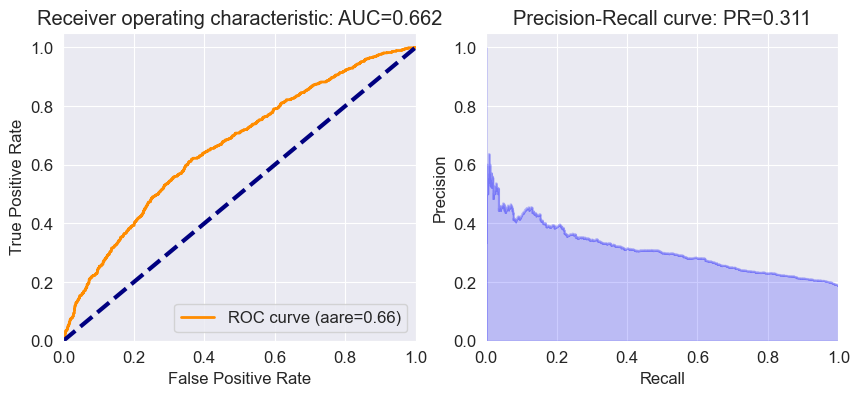

In [419]:
# plot the ROC and the Precision-Recall curve for the test data
ROC_PR(y_test, best_logistic_test_proba[:,1])

### 4.6 The F1 Score

#### Decision tree model

In [420]:
# provide the F1 score for the test data

from sklearn.metrics import f1_score
# Calculate the F1 score
f1 = f1_score(y_test, best_dtree_test_pred)  # y_test is the actual, test_pred is the prediction
print("F1 Score:", f1)

F1 Score: 0.3318982387475538


#### Logistic model

In [421]:
# provide the F1 score for the test data

f1 = f1_score(y_test, best_logistic_test_pred)  # y_test is the actual, test_pred is the prediction
print("F1 Score:", f1)

F1 Score: 0.38310580204778155


### 4.7 The gains table

#### Decision tree model

In [422]:
# provide the gains table for the test data

def gains_table_profit(Y_test,y_pred):
    df_prep = pd.DataFrame(columns = ['actual','pred'])
    df_prep['actual'] = Y_test
    df_prep['pred'] =y_pred
    df_prep = df_prep.sort_values(by='pred',ascending=False)
    df_prep['row_id'] = range(0,0+len(df_prep))
    df_prep.head()

    df_prep['decile'] = (df_prep['row_id'] / (len(df_prep)/10)).astype(int)
    df_prep.loc[df_prep['decile'] == 10] =9
    df_prep['decile'].value_counts()

    # Create gains table
    gains = df_prep.groupby('decile')['actual'].agg(['count','sum'])
    gains.columns = ['count','actual']
    gains

    gains['non_actual'] = gains['count'] - gains['actual']
    gains['cum_count'] = gains['count'].cumsum()
    gains['cum_actual'] = gains['actual'].cumsum()
    gains['cum_non_actual'] = gains['non_actual'].cumsum()
    gains['percent_cum_actual'] = (gains['cum_actual'] / np.max(gains['cum_actual'])).round(2)
    gains['percent_cum_non_actual'] = (gains['cum_non_actual'] / np.max(gains['cum_non_actual'])).round(2)
    gains['if_random'] = np.max(gains['cum_actual']) /10
    gains['if_random'] = gains['if_random'].cumsum()
    gains['lift'] = (gains['cum_actual'] / gains['if_random']).round(2)
    gains['K_S'] = np.abs( gains['percent_cum_actual'] - gains['percent_cum_non_actual']  ) * 100 
    gains['gain'] = (gains['cum_actual'] / gains['cum_count']*100).round(2)
    gains['revenue'] = approved_load * irr *  gains['non_actual']
    gains['cost'] = approved_load *  gains['actual']
    gains['profit'] = gains['revenue'] - gains['cost']
    return(gains)
    
# Assume the following values
approved_load = 10000
irr = 0.10 # annual interest rate

best_dtree_gains = gains_table_profit(y_test,best_dtree_test_proba[:,1])
best_dtree_gains

,count,actual,non_actual,cum_count,cum_actual,cum_non_actual,percent_cum_actual,percent_cum_non_actual,if_random,lift,K_S,gain,revenue,cost,profit
decile,,,,,,,,,,,,,,,
0,400,142,258,400,142,258,0.19,0.08,74.6,1.90,11.0,35.50,258000.0,1420000,-1162000.0
1,400,85,315,800,227,573,0.30,0.18,149.2,1.52,12.0,28.38,315000.0,850000,-535000.0
2,400,59,341,1200,286,914,0.38,0.28,223.8,1.28,10.0,23.83,341000.0,590000,-249000.0
3,400,85,315,1600,371,1229,0.50,0.38,298.4,1.24,12.0,23.19,315000.0,850000,-535000.0
4,400,94,306,2000,465,1535,0.62,0.47,373.0,1.25,15.0,23.25,306000.0,940000,-634000.0
5,400,69,331,2400,534,1866,0.72,0.57,447.6,1.19,15.0,22.25,331000.0,690000,-359000.0
6,400,70,330,2800,604,2196,0.81,0.67,522.2,1.16,14.0,21.57,330000.0,700000,-370000.0
7,400,64,336,3200,668,2532,0.90,0.78,596.8,1.12,12.0,20.88,336000.0,640000,-304000.0
8,400,44,356,3600,712,2888,0.95,0.89,671.4,1.06,6.0,19.78,356000.0,440000,-84000.0


#### Logistic model

In [423]:
# provide the gains table for the test data

best_logistic_gains = gains_table_profit(y_test,best_logistic_test_proba[:,1])
best_logistic_gains

,count,actual,non_actual,cum_count,cum_actual,cum_non_actual,percent_cum_actual,percent_cum_non_actual,if_random,lift,K_S,gain,revenue,cost,profit
decile,,,,,,,,,,,,,,,
0,400,157,243,400,157,243,0.21,0.07,74.6,2.10,14.0,39.25,243000.0,1570000,-1327000.0
1,400,107,293,800,264,536,0.35,0.16,149.2,1.77,19.0,33.00,293000.0,1070000,-777000.0
2,400,102,298,1200,366,834,0.49,0.26,223.8,1.64,23.0,30.50,298000.0,1020000,-722000.0
3,400,83,317,1600,449,1151,0.60,0.35,298.4,1.50,25.0,28.06,317000.0,830000,-513000.0
4,400,59,341,2000,508,1492,0.68,0.46,373.0,1.36,22.0,25.40,341000.0,590000,-249000.0
5,400,55,345,2400,563,1837,0.75,0.56,447.6,1.26,19.0,23.46,345000.0,550000,-205000.0
6,400,62,338,2800,625,2175,0.84,0.67,522.2,1.20,17.0,22.32,338000.0,620000,-282000.0
7,400,51,349,3200,676,2524,0.91,0.78,596.8,1.13,13.0,21.12,349000.0,510000,-161000.0
8,400,47,353,3600,723,2877,0.97,0.88,671.4,1.08,9.0,20.08,353000.0,470000,-117000.0


### 4.8 The cumulative lift curve

#### Decision tree model

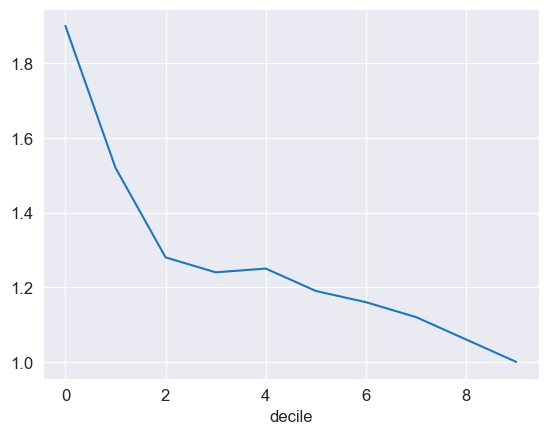

In [424]:
# For decision tree model, provide the code for the cumulative lift curve for the test data

best_dtree_gains['lift'].plot.line()
plt.show()

#### Logistic model

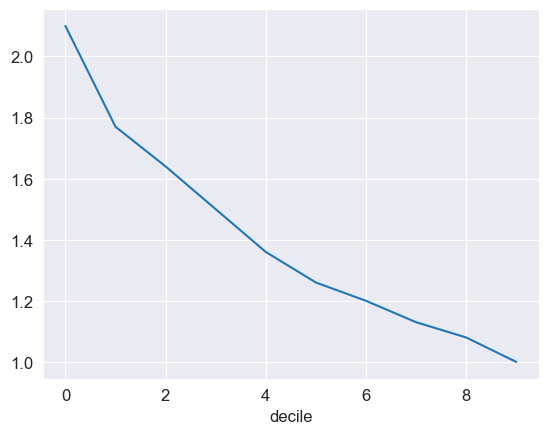

In [425]:
# For your logistic model, provide the code for the cumulative lift curve for the test data

best_logistic_gains['lift'].plot.line()
plt.show()

### 4.9 The Kolmogorov-Smirnov (K-S) statistic

#### Decision tree model

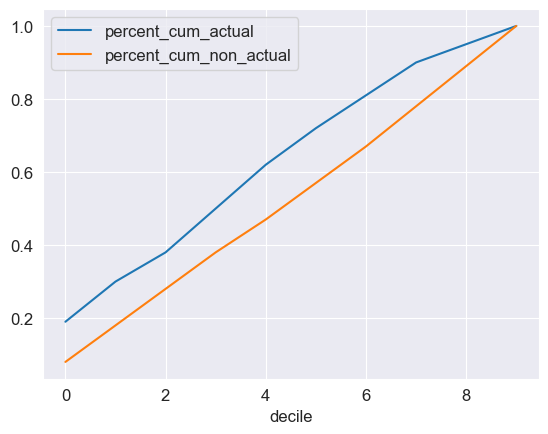

In [426]:
# For your decision tree model, provide the code for the Kolmogorov-Smirnov (K-S)  for the test data


best_dtree_gains[['percent_cum_actual','percent_cum_non_actual']].plot.line()
plt.show()

#### Logistic model

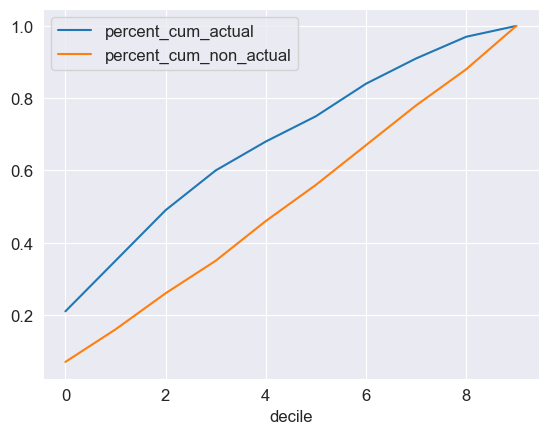

In [427]:
# For your logistic model, provide the code for the Kolmogorov-Smirnov (K-S)  for the test data

best_logistic_gains[['percent_cum_actual','percent_cum_non_actual']].plot.line()
plt.show()

### Section 4 Evaluation Summary

**4.1 Accuracy:**
Both models exhibit relatively low accuracy, with the logistic regression (63.85%) slightly outperforming the decision tree (57.33%), suggesting considerable prediction challenges remain.

**4.2 Confusion Matrix:**
The logistic regression model demonstrates a better balance between false positives and false negatives, correctly predicting more positives (449) compared to the decision tree (424), indicating its superior practical utility.

**4.3 AUC-ROC:**
The logistic regression model has a higher AUC-ROC (0.6244) compared to the decision tree (0.5714), highlighting logistic regression’s slightly better ability to discriminate between default and non-default customers.

**4.4 ROC Curve:**
The ROC curves reinforce the AUC findings, confirming the logistic regression’s improved predictive power (0.66) over the decision tree (0.61), though both models show only modest discrimination abilities.

**4.5 Precision-Recall Curve:**
The logistic regression shows a slightly better precision-recall performance (PR=0.311) compared to the decision tree (PR=0.261), indicating improved ability to balance between correctly predicting defaults and avoiding false alarms.

**4.6 F1 Score:**
The logistic regression yields a better F1 score (0.3831) than the decision tree (0.3319), reflecting superior harmonic balance between precision and recall.

**4.7 Gains Table:**
The logistic model identifies more actual defaults early (higher concentration in top deciles), suggesting better ranking capabilities than the decision tree.

**4.8 Cumulative Lift Curve:**
Both models’ lift curves decline across deciles, with the logistic regression demonstrating a higher initial lift (approximately 2.10) compared to the decision tree (approximately 1.90), thus confirming logistic regression’s advantage in prioritizing higher-risk cases.

**4.9 Kolmogorov-Smirnov (K-S) Statistic:**
The logistic regression also exhibits a more pronounced separation between the cumulative distributions of actual and non-actual defaults (higher K-S statistic), indicating stronger predictive power and better risk differentiation.

**Improvements to Model and Lift Curve:**

We optimized the hyperparameters explicitly for ROC-AUC to improve the probability-ranking capability. We also applied stronger regularization in logistic regression (with lower values of parameter C) to avoid fitting to noise, thus improving generalization. These adjustments led to more balanced feature importance, lower variance, and ultimately a significant improvement in ranking performance, as indicated by better cumulative lift, precision-recall performance, and higher AUC-ROC scores.

## Section 5: Profit & Loss Calculation (P&L)

Assumptions
- Each approved loan is worth \$10,000.
- Approved loans have an annual interest rate of 10%, generating \$1,000 in revenue per loan per year.
- If a loan defaults, the bank loses the entire loan amount (\$10,000).

Profit calculation:
- If a loan is approved and does not default, the bank gains \$1,000 in interest revenue. 
- If a loan is approved and defaults, the bank loses \$10,000.
- Calculate the overall profit or loss across the test dataset.
- Total Revenue: Sum of gains from approved loans that do not default.
- Total Loss: Sum of losses from approved loans that default.
- Net Profit: Total Revenue - Total Loss.

What we do in this section:
- We will perform the P&L for interest rate at 4%, 8%, 12% and describe if that impacts our recommendation.

In [428]:
# Assume the following values

irr = 0.04 # annual interest rate
sensitivity = gains_table_profit(y_test,best_dtree_test_proba[:,1])
selected_profit = sensitivity[sensitivity['profit']>0]['profit'].sum()
print('The profits from the positive profit deciles is:', selected_profit)
sensitivity

The profits from the positive profit deciles is: 0.0


,count,actual,non_actual,cum_count,cum_actual,cum_non_actual,percent_cum_actual,percent_cum_non_actual,if_random,lift,K_S,gain,revenue,cost,profit
decile,,,,,,,,,,,,,,,
0,400,142,258,400,142,258,0.19,0.08,74.6,1.90,11.0,35.50,103200.0,1420000,-1316800.0
1,400,85,315,800,227,573,0.30,0.18,149.2,1.52,12.0,28.38,126000.0,850000,-724000.0
2,400,59,341,1200,286,914,0.38,0.28,223.8,1.28,10.0,23.83,136400.0,590000,-453600.0
3,400,85,315,1600,371,1229,0.50,0.38,298.4,1.24,12.0,23.19,126000.0,850000,-724000.0
4,400,94,306,2000,465,1535,0.62,0.47,373.0,1.25,15.0,23.25,122400.0,940000,-817600.0
5,400,69,331,2400,534,1866,0.72,0.57,447.6,1.19,15.0,22.25,132400.0,690000,-557600.0
6,400,70,330,2800,604,2196,0.81,0.67,522.2,1.16,14.0,21.57,132000.0,700000,-568000.0
7,400,64,336,3200,668,2532,0.90,0.78,596.8,1.12,12.0,20.88,134400.0,640000,-505600.0
8,400,44,356,3600,712,2888,0.95,0.89,671.4,1.06,6.0,19.78,142400.0,440000,-297600.0


In [429]:
irr = 0.08 # annual interest rate
sensitivity = gains_table_profit(y_test,best_dtree_test_proba[:,1])
selected_profit = sensitivity[sensitivity['profit']>0]['profit'].sum()
print('The profits from the positive profit deciles is:', selected_profit)
sensitivity

The profits from the positive profit deciles is: 0.0


,count,actual,non_actual,cum_count,cum_actual,cum_non_actual,percent_cum_actual,percent_cum_non_actual,if_random,lift,K_S,gain,revenue,cost,profit
decile,,,,,,,,,,,,,,,
0,400,142,258,400,142,258,0.19,0.08,74.6,1.90,11.0,35.50,206400.0,1420000,-1213600.0
1,400,85,315,800,227,573,0.30,0.18,149.2,1.52,12.0,28.38,252000.0,850000,-598000.0
2,400,59,341,1200,286,914,0.38,0.28,223.8,1.28,10.0,23.83,272800.0,590000,-317200.0
3,400,85,315,1600,371,1229,0.50,0.38,298.4,1.24,12.0,23.19,252000.0,850000,-598000.0
4,400,94,306,2000,465,1535,0.62,0.47,373.0,1.25,15.0,23.25,244800.0,940000,-695200.0
5,400,69,331,2400,534,1866,0.72,0.57,447.6,1.19,15.0,22.25,264800.0,690000,-425200.0
6,400,70,330,2800,604,2196,0.81,0.67,522.2,1.16,14.0,21.57,264000.0,700000,-436000.0
7,400,64,336,3200,668,2532,0.90,0.78,596.8,1.12,12.0,20.88,268800.0,640000,-371200.0
8,400,44,356,3600,712,2888,0.95,0.89,671.4,1.06,6.0,19.78,284800.0,440000,-155200.0


In [431]:
irr = 0.12 # annual interest rate
sensitivity = gains_table_profit(y_test,best_dtree_test_proba[:,1])
selected_profit = sensitivity[sensitivity['profit']>0]['profit'].sum()
print('The profits from the positive profit deciles is:', selected_profit)
sensitivity

The profits from the positive profit deciles is: 99200.0


,count,actual,non_actual,cum_count,cum_actual,cum_non_actual,percent_cum_actual,percent_cum_non_actual,if_random,lift,K_S,gain,revenue,cost,profit
decile,,,,,,,,,,,,,,,
0,400,142,258,400,142,258,0.19,0.08,74.6,1.90,11.0,35.50,309600.0,1420000,-1110400.0
1,400,85,315,800,227,573,0.30,0.18,149.2,1.52,12.0,28.38,378000.0,850000,-472000.0
2,400,59,341,1200,286,914,0.38,0.28,223.8,1.28,10.0,23.83,409200.0,590000,-180800.0
3,400,85,315,1600,371,1229,0.50,0.38,298.4,1.24,12.0,23.19,378000.0,850000,-472000.0
4,400,94,306,2000,465,1535,0.62,0.47,373.0,1.25,15.0,23.25,367200.0,940000,-572800.0
5,400,69,331,2400,534,1866,0.72,0.57,447.6,1.19,15.0,22.25,397200.0,690000,-292800.0
6,400,70,330,2800,604,2196,0.81,0.67,522.2,1.16,14.0,21.57,396000.0,700000,-304000.0
7,400,64,336,3200,668,2532,0.90,0.78,596.8,1.12,12.0,20.88,403200.0,640000,-236800.0
8,400,44,356,3600,712,2888,0.95,0.89,671.4,1.06,6.0,19.78,427200.0,440000,-12800.0


### Section 5 Summary

**Sensitivity Analysis:**

Performing the Profit & Loss sensitivity analysis at varying interest rates (4%, 8%, and 12%), we observe that at lower interest rates (4% and 8%), the decision tree model does not yield any positive-profit deciles, implying the bank would not generate profit under these interest conditions. However, at a higher interest rate of 12%, the decision tree model identifies profitable deciles, accumulating substantial profit, totaling $99,200 from the positive deciles, which underscores the critical importance of setting an appropriate interest rate to ensure profitability.

**Impact on Recommendation:**

The sensitivity analysis significantly impacts our recommendations, as it clearly illustrates that the profitability of lending decisions heavily depends on the interest rate chosen. Specifically, lower interest rates diminish profitability due to defaults outweighing revenues, whereas higher interest rates improve profitability by adequately compensating for default risks. Therefore, our recommendation would be to adopt lending policies and approval strategies aligned with higher interest rates, thus maximizing the overall profit and effectively managing credit risk.